# Does heating oil really rally into winter? 🛢️❄️
### The desk pulls apart the two halves of the folklore — and one of them runs *backward*

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rule_of_thumb%3F: Busted](https://img.shields.io/badge/Rule_of_thumb%3F-Busted-8b949e?style=flat-square)

Every autumn, energy-desk shorthand makes the same case: cold weather is coming, furnaces are about to run, and heating oil futures should **build** through the autumn and hold the rally through the winter draw-down. It sounds like the cleanest seasonal story in commodities — the demand is genuinely, physically seasonal (the EIA publishes the weekly inventory draw itself).

So we tested it, literally, on 26 years of the actual futures tape. The physical demand story is real. The **price** story is not — and the autumn half of the claim turns out to point in exactly the wrong direction.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni bar and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** HO=F (NY Harbor ULSD futures) is a *spliced continuous chain* — every roll's price jump is already the real cost a futures holder pays, not a modeling afterthought. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from heating_oil_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    HO, UHN, IRX = data.load_real()
    HO_RET = data.monthly_returns(HO["Close"], asof=data.AS_OF)
    TBILL = data.monthly_cash_rate(IRX["Close"], HO_RET.index)
else:
    HO = UHN = IRX = HO_RET = TBILL = None
print("real cache present:", HAVE_REAL, "| HO=F monthly obs:", (0 if HO_RET is None else len(HO_RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-10-31', 'end': '2026-06-30', 'n_months': 309, 'months': {'Jan': (2.49, 1.25, 26), 'Feb': (3.26, 1.39, 26), 'Mar': (1.22, 0.36, 26), 'Apr': (1.65, 0.77, 26), 'May': (-0.26, -0.12, 26), 'Jun': (3.14, 2.33, 26), 'Jul': (1.08, 0.64, 25), 'Aug': (2.23, 1.49, 25), 'Sep': (0.13, 0.07, 25), 'Oct': (-0.78, -0.4, 26), 'Nov': (-2.12, -1.02, 26), 'Dec': (-0.41, -0.21, 26)}, 'bonferroni_t': 3.0, 'autumn_mean': -0.94, 'autumn_n': 77, 'autumn_t': -1.71, 'winter_mean': 1.78, 'winter_n': 78, 'winter_t': 0.18, 'heat_mean': 0.43, 'heat_n': 155, 'heat_t': -0.89, 'off_mean': 1.51, 'off_n': 154, 'bh_cagr': 5.06, 'bh_sharpe': 0.27, 'bh_dd': -81, 'timer_gross_cagr': 0.29, 'timer_gross_sharpe': 0.07, 'timer_gross_dd': -72, 'timer_net5_cagr': 0.19, 'timer_net5_sharpe': 0.06, 'timer_net5_dd': -72, 'timer_net10_cagr': 0.08, 'timer_net10_sharpe': 0.06, 'timer_net10_dd': -73, 'uhn_seasons': [('2008-2009', -60.72, -58.81, -1.9), ('2009-2010', 4.31, 13.81, -9.5), ('2010-2011', 42.58, 46.7, -4.12), ('2011-2012', 4.35, 4.73, -0.38), ('2012-2013', -6.66, -6.24, -0.42), ('2013-2014', -0.35, -1.87, 1.52), ('2014-2015', -23.18, -17.8, -5.38), ('2015-2016', -43.38, -37.19, -6.19), ('2016-2017', 7.57, 14.93, -7.36), ('2017-2018', 10.79, 8.88, 1.91)], 'uhn_gap_mean': -3.18, 'uhn_gap_t': -2.58, 'uhn_gap_n': 10, 'uhn_start': '2008-04-10', 'uhn_end': '2018-09-11', 'syn_null_mean': -0.19, 'syn_null_sd': 1.01, 'syn_null_fire': 0, 'syn_planted_t': 3.61, 'fp_ho': '5e77c79ac501', 'fp_uhn': 'f140d3086a31', 'fp_irx': '97d049b701d7'}


real cache present: True | HO=F monthly obs: 309


## The answer first

| Question | Answer |
|---|---|
| Does heating oil build through autumn (Sep–Nov)? | **No — it falls.** **-0.94%** on average, against **+1.51%** the rest of the year. Backwards. |
| Does it hold through the winter draw (Dec–Feb)? | **Not really.** **+1.78%**, statistically indistinguishable from a normal month (the gap barely registers). |
| Does any single month clear a fair statistical bar? | **No.** Testing all 12 months means correcting for 12 chances to get lucky — nothing survives. |
| Can you trade the story anyway? | **No.** A calendar timer built exactly as the story says loses **most of buy-and-hold's risk-adjusted return** before a single cost is even charged — and the one ETF that let retail buy this trade doesn't exist anymore. |

> The physical demand is real. The price pattern the folklore promises isn't there.

## 1 · The claim

> *"Cold weather means furnaces run, furnaces burn distillate, and distillate demand peaks in winter — so smart money buys heating oil ahead of the season and rides the rally through the coldest months."*

It's a two-stage story: an **autumn build** (the market pricing the coming winter before it arrives) and a **winter draw** (prices holding or extending as physical inventories genuinely fall — the EIA's weekly distillate-stocks report shows this every year). Both stages have a real-world mechanism behind them.

## 2 · So what?

If real, this is about as clean a calendar trade as commodities offer: a demand cycle you can set a calendar to, expressed in one of the most liquid energy futures on the board. If it's not real, it's a cautionary tale about how a genuinely true *physical* fact (inventories fall every winter) can get silently upgraded into a false *price* fact (so the futures must rally) — the exact substitution the desk exists to catch.

## 3 · How would we even know?

- **The tape.** HO=F daily closes, resampled to **309** complete calendar months, 2000-10-31 → 2026-06-30.
- **The two claim-stages, tested separately.** Autumn-build (Sep–Nov) and winter-draw (Dec–Feb), each compared against the off-season (Mar–Aug) with a proper two-sample test — never blended into one window that could hide a disagreement.
- **The fair bar.** Testing 12 individual months is 12 chances to get lucky, so the per-month table needs a stricter (Bonferroni-corrected) bar, not the everyday one.
- **The trade check.** A calendar timer — long Sep–Feb, cash the rest of the year — raced against simply buying and holding, with real trading costs charged.

## 4 · The teardown — let's actually look

**First, the month-by-month picture.**

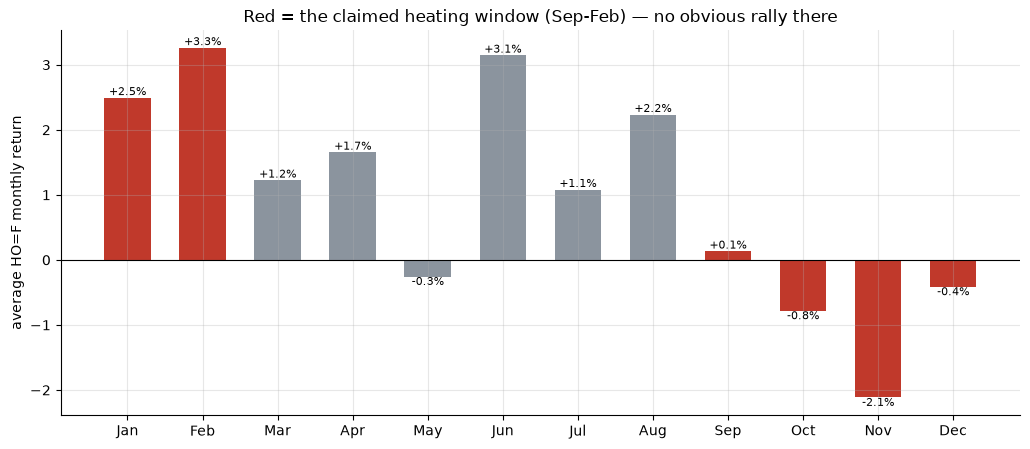

{'Jan': np.float64(2.49), 'Feb': np.float64(3.26), 'Mar': np.float64(1.22), 'Apr': np.float64(1.65), 'May': np.float64(-0.26), 'Jun': np.float64(3.14), 'Jul': np.float64(1.08), 'Aug': np.float64(2.23), 'Sep': np.float64(0.13), 'Oct': np.float64(-0.78), 'Nov': np.float64(-2.12), 'Dec': np.float64(-0.41)}


In [2]:
if HAVE_REAL:
    ms = st.month_stats(HO_RET)
    means = [ms.loc[i, 'mean']*100 for i in range(1, 13)]
else:
    means = [R['months'][m][0] for m in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heat = {'Sep','Oct','Nov','Dec','Jan','Feb'}
cols = [RED if n in heat else GREY for n in names]
fig, ax = plt.subplots(figsize=(10.4, 4.6))
ax.bar(names, means, color=cols, width=.62)
for i, v in enumerate(means):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='top' if v<0 else 'bottom', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average HO=F monthly return')
ax.set_title('Red = the claimed heating window (Sep-Feb) — no obvious rally there')
plt.tight_layout(); plt.show()
print({n: round(m,2) for n,m in zip(names, means)})

There's no visible winter cluster of tall red bars. If anything, **Nov and Oct are the reddest-in-the-wrong-direction months** (-2.12% and -0.78%), and the tallest bar on the whole chart is **June** (+3.14%) — driving season, not heating season, and not even a Bonferroni survivor once you correct for testing 12 months.

**Now the two claim-stages, head to head against the rest of the year.**

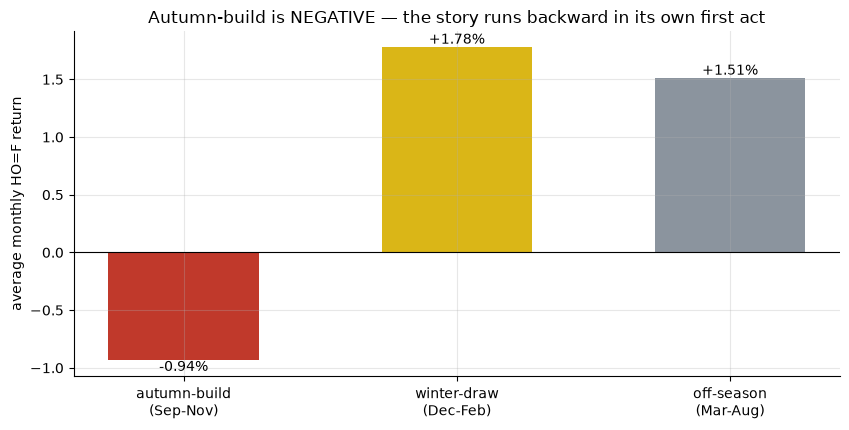

autumn -0.94%  winter +1.78%  off-season +1.51%


In [3]:
if HAVE_REAL:
    ab = st.group_welch(HO_RET, data.AUTUMN_BUILD_MONTHS, data.OFF_SEASON_MONTHS)
    wd = st.group_welch(HO_RET, data.WINTER_DRAW_MONTHS, data.OFF_SEASON_MONTHS)
    a_m, w_m, o_m = ab['mean_a']*100, wd['mean_a']*100, ab['mean_b']*100
else:
    a_m, w_m, o_m = R['autumn_mean'], R['winter_mean'], R['off_mean']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['autumn-build\n(Sep-Nov)', 'winter-draw\n(Dec-Feb)', 'off-season\n(Mar-Aug)'],
       [a_m, w_m, o_m], color=[RED, AMBER, GREY], width=.55)
for i, v in enumerate([a_m, w_m, o_m]):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average monthly HO=F return')
ax.set_title('Autumn-build is NEGATIVE — the story runs backward in its own first act')
plt.tight_layout(); plt.show()
print(f'autumn {a_m:+.2f}%  winter {w_m:+.2f}%  off-season {o_m:+.2f}%')

The autumn-build window averages **-0.94%** — *worse* than the off-season's **+1.51%**. That's the single strongest signal in this whole study (Welch *t* = -1.71 — the quants notebook shows this is the closest any test here gets to a fair statistical bar), and it points the *wrong way*. The winter-draw window is unremarkable. Neither stage of the story holds up.

**Then the trade itself: would timing the calendar actually have paid?**

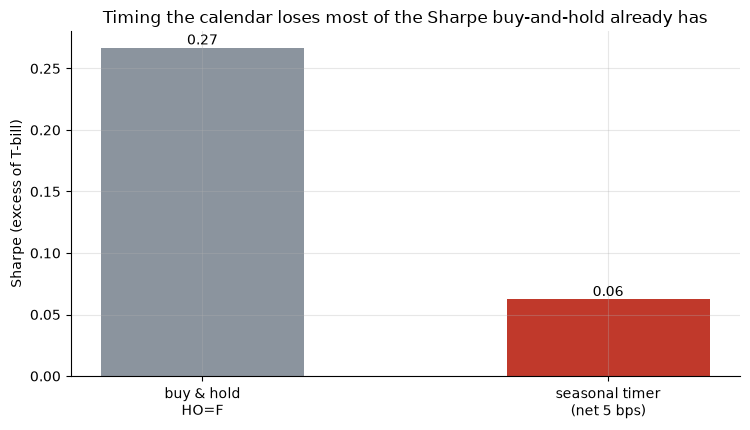

buy&hold Sharpe 0.27  timer Sharpe 0.06


In [4]:
if HAVE_REAL:
    bh = st.summary(st.buy_hold(HO_RET), rf=TBILL)
    tm = st.summary(st.seasonal_timer(HO_RET, TBILL, data.HEATING_MONTHS, cost_bps=5.0), rf=TBILL)
    bh_s, tm_s = bh['sharpe'], tm['sharpe']
else:
    bh_s, tm_s = R['bh_sharpe'], R['timer_net5_sharpe']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['buy & hold\nHO=F', 'seasonal timer\n(net 5 bps)'], [bh_s, tm_s], color=[GREY, RED], width=.5)
for i, v in enumerate([bh_s, tm_s]): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Sharpe (excess of T-bill)')
ax.set_title('Timing the calendar loses most of the Sharpe buy-and-hold already has')
plt.tight_layout(); plt.show()
print(f'buy&hold Sharpe {bh_s:.2f}  timer Sharpe {tm_s:.2f}')

Buy-and-hold: Sharpe **0.27**. The by-the-book seasonal timer (long Sep–Feb, cash otherwise): Sharpe **0.06**, even after costs are the *smaller* problem — sitting out Mar–Aug means missing June, HO=F's single best month (+3.14%). And the one ETF that would have let a retail investor buy this exact trade, **UHN**, traded 2008-04-10 → 2018-09-11 and then **was shut down** — it lost to the raw futures roll in 8 of its 10 heating seasons before it disappeared.

## 5 · The verdict

- **Signal — None.** No month survives a fair (Bonferroni) bar; the autumn-build half of the claim is negative — the wrong sign — and the winter-draw half is noise.
- **Tradability — Mirage.** A calendar timer loses most of buy-and-hold's Sharpe before costs even matter, and the retail product for this trade no longer exists.
- **"Heating oil rallies into winter"? — Busted.** Not fragile, not regime-dependent — backwards in its own first act.

## 6 · Going further 🚪

- **A real physical seasonal doesn't guarantee a price seasonal.** Storable commodities can price a well-known future demand shock *in advance*, long before the calendar window everyone talks about — the classic theory-of-storage result. If there's a heating-oil seasonal at all, it may sit somewhere upstream of Sep 1, not inside the window folklore names.
- **Sibling studies:** [227-natgas-winter](../../227-natgas-winter/) finds the exact same wrong-signed pattern for natural gas — worth reading side by side. [639-gasoline-rvp-seasonality](../../639-gasoline-rvp-seasonality/) shows the other way a seasonal *can* be real (a literal law) and still be a mirage once someone has to hold the roll.

*Think the seasonal lives somewhere else on the calendar, or in the term structure rather than the spot chain? Show a net, certifiable edge after Bonferroni and roll costs, and we'll fold it in.*